In [35]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag
import datetime
import json

In [36]:
def check_fired(reports):
    """
    Confirm every tag actually fired, and against the same blank.

    A tag that never fired answers with "pending":0 and two reject
    tallies. Which one climbed says what to change:

      rej_short  the floor was reached but the carrier came back before
                 ESYNC_BLANK_MIN_US -- a fade, or the blank is shorter
                 than the firmware expects
      it stays 0 nothing ever reached the floor, so no edge was ever
                 latched. The falling edge IS the floor test, so this is
                 the only other thing it can be. Compare min_mv against
                 base_mv: if min_mv never gets near ESYNC_MIN_BASELINE_MV
                 the blank is not deep enough at this tag.

    A tag that DID fire still has to be checked, which is new. The
    detector times off the FALLING edge and commits before the blank's
    length is known, so an overrunning blank cannot be rejected -- it is
    fired against and only flagged afterwards. "returned":0 means the
    carrier had not come back by the time the tag fired; "long":1 means
    the blank exceeded ESYNC_BLANK_MAX_US. Either way the shot happened
    somewhere the exciter did not intend.
    """
    for name, r in reports.items():
        print(f"{name}: {r}")

    for name, r in reports.items():
        if "low_us" in r and "pending" not in r:
            continue
        raise Exception(
            f"{name} never fired: rej_short={r.get('rej_short')} "
            f"in_blank={r.get('in_blank')} armed={r.get('armed')} "
            f"min_mv={r.get('min_mv')} base_mv={r.get('base_mv')}"
        )

    for name, r in reports.items():
        if not r.get("returned"):
            raise Exception(
                f"{name} fired blind: the carrier still had not returned "
                f"{r.get('delay_us')} us after the falling edge, so the tag "
                f"acted mid-blank. The blank is longer than "
                f"ESYNC_FIRE_DELAY_US assumes -- check DROP_MS and N in "
                f"manual_null_exciter.py against ESYNC_FIRE_DELAY_US and "
                f"ESYNC_TIME_SCALE in config.h."
            )
        if r.get("long"):
            print(f"WARNING {name}: blank ran long ({r['low_us']} us) -- "
                  f"synced against an outage?")

    # t_us is each tag's own uptime, so it is NOT comparable between tags.
    # low_us is a measured duration, so it is. Read it as an approximation:
    # it spans the floor on the way down to ESYNC_REARM_PCT on the way up,
    # two different thresholds, so it under-reads DROP_MS by a millisecond
    # or two. What matters is that the tags AGREE. A wide spread means one
    # of them timed off a different edge; a shared drift of many ms from
    # delay_us means the two hardcoded lengths have come apart.
    lows = [r["low_us"] for r in reports.values()]
    nominal = next(iter(reports.values())).get("delay_us")
    print(f"all tags fired; blank measured {min(lows)}..{max(lows)} us "
          f"(spread {max(lows) - min(lows)} us, expected {nominal} us)")
    return lows


In [37]:
com_port1="/dev/tty.usbmodem101"
tag1=Tag(com_port1)
ip_port_out = tag1.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag1.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag1.get_mac_wifi())

com_port2="/dev/tty.usbmodem2101"
tag2=Tag(com_port2)
ip_port_out = tag2.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag2.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag2.get_mac_wifi())


{'net': 'up', 'ip': '10.202.78.216', 'port': 3333, 'rssi': -41}
58:E6:C5:01:08:CC
{'net': 'up', 'ip': '10.202.78.169', 'port': 3333, 'rssi': -52}
B4:3A:45:8A:BC:30


In [38]:
# Queue BEFORE arming. esync makes the firmware suspend the radio within
# ESYNC_WIFI_QUIET_MS of acking, so anything sent after it never lands.
#
# Then trigger one blank from the exciter:
#
#     python3 BladeRFCode/null_sync/manual_null_exciter.py     -> press Enter
#
# DROP_MS there must EQUAL ESYNC_FIRE_DELAY_US in the firmware's config.h
# (and N must equal ESYNC_TIME_SCALE), with the tags flashed to match --
# the detector works in absolute microseconds and cannot infer it off the
# air. Since the tag dead-reckons from the falling edge, a mismatch does
# not stop it firing, it just fires at the wrong moment; check_fired()
# below catches that from low_us rather than you seeing it fail.
tag1.queue_adc_read_wifi(830)
tag2.queue_mpp_wifi(1)

tag1.listen_esync_wifi()
tag2.listen_esync_wifi()

# Blocks until each radio is back: either the blank arrived, or the
# firmware gave up after ESYNC_WIFI_TIMEOUT_MS.
tag1.reconnect_wifi()
tag2.reconnect_wifi()

# The replies were buffered in RAM while the radio was down; pull them.
# tag2 runs the sweep and only answers with a status line -- the trace worth
# plotting is tag1's adc reply, recorded across tag2's sweep.
mpp_data  = tag1.fetch_queued_wifi()   # {"info":"adc",...,"data":"..."}
sweep_ack = tag2.fetch_queued_wifi()   # {"info":"mpp",...,"ok":1}

for name, data in (("tag1", mpp_data), ("tag2", sweep_ack)):
    if data.get("pending") == 0:
        raise Exception(f"{name}: no queued reply -- esync window timed out")

# Both tags time off the FALLING edge that starts the blank and fire
# ESYNC_FIRE_DELAY_US later, landing as the carrier returns.
check_fired({"tag1": tag1.esync_report_wifi(),
             "tag2": tag2.esync_report_wifi()})
print("tag2 sweep:", sweep_ack)


b'q:queued, adc_830\n' 	 b'q:queued, adc_830\n'
b'q:queued, mpp_1\n' 	 b'q:queued, mpp_1\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'
tag1: {'info': 'esync', 'edge': 'fall', 't_us': 820238132, 'fire_us': 820288147, 'delay_us': 50000, 'low_us': 46052, 'returned': 1, 'long': 0, 'min_mv': 0.381, 'base_mv': 125.429}
tag2: {'info': 'esync', 'edge': 'fall', 't_us': 791302212, 'fire_us': 791352226, 'delay_us': 50000, 'low_us': 45499, 'returned': 1, 'long': 0, 'min_mv': 0.381, 'base_mv': 138.476}
all tags fired; blank measured 45499..46052 us (spread 553 us, expected 50000 us)
tag2 sweep: {'info': 'mpp', 'ch': 8, 'passes': 1, 'ok': 1}


120.775
data is fine
segment 0 [380, 455): 75 readings
segment 1 [455, 530): 75 readings
segment 2 [530, 605): 75 readings
segment 3 [605, 680): 75 readings
segment 4 [680, 755): 75 readings
segment 5 [755, 830): 75 readings


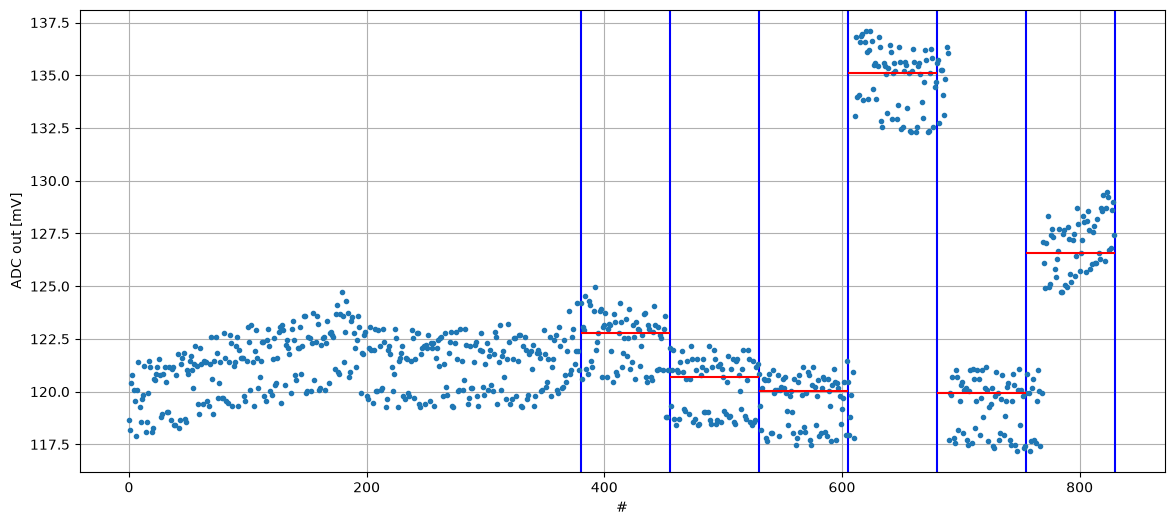

2026-09-07 14:30:38


In [39]:
def plotMPPSegments(data, seg_size=75, n_segments=6):
    """
    Plot an adc reply and split its tail into n_segments vertical segments of
    seg_size samples, counted from the back of the trace. Whatever comes before
    the first boundary is still plotted, just not segmented.
    """
    if isinstance(data, dict):
        data = data['data']
    if isinstance(data, str):
        data = list(map(float, data.split(',')))
        
    voltage = np.asarray(data, dtype=float)
    print(np.median(voltage[:100]))
    if np.median(voltage[:100])<5:
        print("Bad data")
    else:
        print("data is fine")
    
    idx = np.arange(len(voltage))

    # Boundaries walked backwards from the last sample, then flipped so the
    # segments come out in ascending index order. Clamped at 0 for short traces.
    edges = sorted({max(len(voltage) - seg_size * i, 0) for i in range(n_segments + 1)})

    plt.figure(figsize=(14, 6))
    for e in edges:
        plt.axvline(x=e, color='b')

    plt.plot(idx, voltage, '.')

    for seg, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        in_segment = (idx >= left) & (idx < right)
        print(f"segment {seg} [{left}, {right}): {np.count_nonzero(in_segment)} readings")
        if not np.any(in_segment):
            continue
        plt.hlines(np.median(voltage[in_segment]), left, right, color='r', zorder=3)

    plt.xlabel("#")
    plt.ylabel("ADC out [mV]")
    plt.grid()
    # plt.ylim([50,150])
    plt.show()



plotMPPSegments(mpp_data)



print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

